In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

In [2]:
# Load dataset
df = pd.read_csv("HousingData.csv")

In [3]:
# Basic info
print(df.shape)
print(df.head())
print(df.info())

# Handle missing values
print(df.isnull().sum())
df.dropna(inplace=True)
print(df.isnull().sum())

(506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null

In [4]:
# Features and target
x = df.drop(columns=["MEDV"])
y = df["MEDV"]

In [5]:
# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [6]:
# Feature scaling (FIXED)
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)   # ✅ Corrected line

In [7]:
# Build model
model = Sequential()
model.add(Dense(64, activation="relu", input_dim=13))
model.add(Dense(32, activation="relu"))
model.add(Dense(1))   # Linear output for regression


C:\Users\Rutuja Varunkar\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# Compile model
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [9]:
# Early stopping (optional but good)
early_stop = EarlyStopping(monitor='val_loss', patience=10)

In [10]:
# Train model
history = model.fit(
    x_train_scaled, 
    y_train,
    batch_size=16,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stop])

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 559.4846 - mae: 21.6512 - val_loss: 490.0804 - val_mae: 20.7344
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 504.1815 - mae: 20.4496 - val_loss: 438.7977 - val_mae: 19.5479
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 436.4438 - mae: 18.9045 - val_loss: 369.6864 - val_mae: 17.8353
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 348.2313 - mae: 16.7184 - val_loss: 280.9651 - val_mae: 15.3467
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 238.8010 - mae: 13.6791 - val_loss: 185.3662 - val_mae: 12.0022
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 138.8920 - mae: 10.0264 - val_loss: 103.7079 - val_mae: 8.0114
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 69.8973 - mae: 6.7386 - val_loss: 64.0198 - val_mae: 5.8259
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 44.5624 - mae: 5.3182 - val_loss: 48.1249 - val_mae: 5.0124
Epoch 9/100
16/16 ━━━━━━

In [11]:
# Predictions
y_pred = model.predict(x_test_scaled).flatten()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


In [12]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", mae)
print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Mean Absolute Error : 2.6184567801560035
Mean Squared Error : 23.81449437697709
Root Mean Squared Error : 4.8800096697626625
R2 Score : 0.7176585219145395


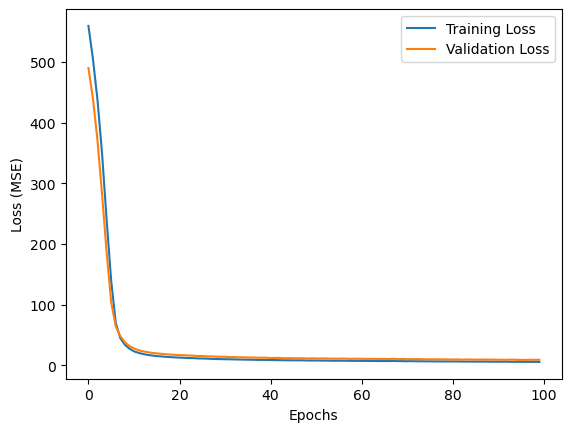

In [13]:
# Plot loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

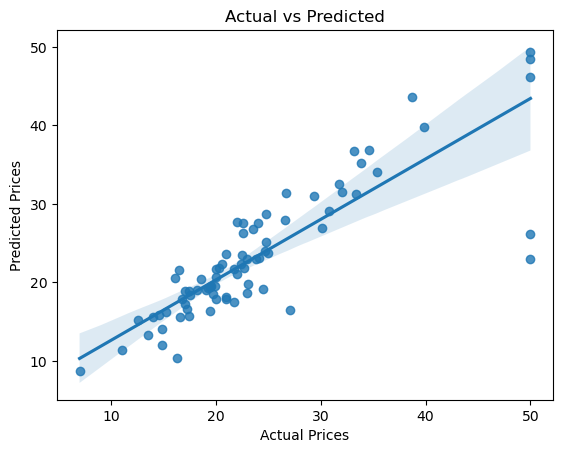

In [14]:
# Plot Actual vs Predicted
sns.regplot(x=y_test, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

In [15]:
results = pd.DataFrame(
    {
    "Actual": y_test.values,
    "Predicted": y_pred
    }
                      )

print(results.head(10))

   Actual  Predicted
0    25.0  23.716124
1    18.6  20.386383
2    21.0  18.153740
3    23.5  26.810329
4    17.5  18.353828
5    33.8  35.192509
6    19.7  18.581776
7    24.8  28.725183
8    32.0  31.503059
9    14.0  15.637314
